### note
<br/>

### note name

In [1]:
# pip install ipynbname

import ipynbname
nb_name = ipynbname.name()
nb_path = ipynbname.path()

nb_name

'2Samples Classical_GRU_P151 SEEDs_ini_2'

## Hyper parameters

In [2]:
SEED = 2
# SEEDs = range(10) # 0~9
L_RATE = 0.2 # 0.2
N_STEPS = 1000000
NUM_SEEDs = 50

In [3]:
from jax.config import config
config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import pennylane as qml
from jax.example_libraries import optimizers
from jax.example_libraries import stax
from jax import value_and_grad
from jax import lax

import optax
# from functools import partial
import time
import matplotlib.pyplot as plt
import pickle


from SQGRU_j7x import SQGRU, qgru
from Classical_RNN import simple_rnn, gru, count_parameters

### force to use cpu

In [4]:
jax.config.update('jax_platform_name', 'cpu')

In [5]:
qml.version()

'0.31.1'

## Oscillations

In [6]:
def damped_shm(fre, damp):
    amp = 0.7
    num_data = 151
    x = jnp.array(range(num_data))
    y = jnp.sin(x*fre)*jnp.exp(x*damp)*amp

    return y

In [7]:
osc1 = damped_shm(0.4, 0)
osc2 = damped_shm(0.6, -0.02)

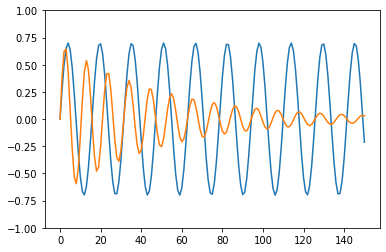

In [8]:
plt.plot(osc1)
plt.plot(osc2)
plt.ylim(-1,1)
plt.show()

In [9]:
oscillations = jnp.array([osc1,osc2])
true_data = jnp.expand_dims(oscillations, 2)
train_input = true_data[:,0:100,:]
train_target = true_data[:,1:101,:]

## Model
### Hyper parameters

In [10]:
# model parameters
OUT_DIM = 6

In [11]:
init_fun, qgru_rnn = stax.serial(gru(OUT_DIM, sequence_out=True), stax.Dense(1))

In [12]:
key = jax.random.PRNGKey(SEED)
key1, key2 = jax.random.split(key, num=2)
_, params = init_fun(key1, jnp.shape(train_input))

In [13]:
count_parameters(params)

151

## Train

In [14]:
step_size = L_RATE
optimizer = optax.adam(step_size)
opt_state = optimizer.init(params)

In [15]:

@jax.jit
def loss_fn(params, xs, ys):
#     prediction = qgru_rnn(params, xs)[:,:,0:1]
    prediction = qgru_rnn(params, xs)
#     prediction = cls_predict(xs, 10, params)
    
    return jnp.mean((prediction - ys)**2) # the prediction shape


# def update(i_step, params, xs, ys, opt_state):
#     loss, grads = value_and_grad(loss_fn)(params, xs, ys)
#     updates, opt_state = optimizer.update(grads, opt_state)
#     params = optax.apply_updates(params, updates)
#     return params, opt_state, loss


In [16]:
minLoss = 1000
best_params = params
lossList = []
loc_params_list = []
reset_steps = []

In [17]:
def ck_lr(old_lr, new_lr):
    d_lr = old_lr - new_lr
    return d_lr >= 0 and d_lr/new_lr < 1e-2

### prediction

In [18]:
_, qgru_rnn2 = stax.serial(gru(OUT_DIM, sequence_out=True), stax.Dense(1))

In [19]:
@jax.jit
def jit_rnn(params, inputs):
    return qgru_rnn2(params, inputs)

In [20]:
true1 = true_data.squeeze()[:,0:100]
true2 = true_data.squeeze()[:,100:]
xs = train_input

In [21]:
# for classical rnn to predict the trend
def cls_predict(inp, pred_length, params):
    ys = jit_rnn(params, inp)
    new_inp = inp
    for _ in range(pred_length-1):
        new_inp = jnp.concatenate([new_inp, ys[:,-1:]], axis=1)
        ys = jit_rnn(params, new_inp)
    return ys

### start

In [22]:
update_lr = True
lr_factor = 1
locLossList = [1000,1000,1000]
locLoss = 1000
loc_params = params



start = time.time()
for i in range(N_STEPS):
    
    if update_lr != 0:
        if update_lr < 0:
            params = loc_params
        else:
            locLossList = [1000,1000,1000]
            locLoss = 1000
            loc_params_list.append(loc_params)
            reset_steps.append(i)
            # reset parameters
            key1, key2 = jax.random.split(key2, num=2)
            _, params = init_fun(key1, jnp.shape(train_input))
            loc_params = params
            # stop when collect X local best parameters
            if len(loc_params_list) > NUM_SEEDs:
                break
        update_lr = 0
            
        # update learning rate
        optimizer = optax.adam(step_size)
        opt_state = optimizer.init(params)
        
        print('learning rate:', step_size)

        def update(i_step, params, xs, ys, opt_state):
            loss, grads = value_and_grad(loss_fn)(params, xs, ys)
            updates, opt_state = optimizer.update(grads, opt_state)
            params = optax.apply_updates(params, updates)
            return params, opt_state, loss
    
    pre_params = params
    params, opt_state, loss = update(i, params, train_input, train_target, opt_state)
    print('{}: {}   {} sec      '.format(i, loss, time.time()-start), end='\r')
    if loss < minLoss:
        best_params = pre_params
        minLoss = loss
    if loss < locLoss:
        loc_params = pre_params
        locLoss = loss
    if (i+1) % 100 == 0:
        # update learning rate?
        if loss > locLossList[0] and locLossList[1] > locLossList[0] and locLossList[2] > locLossList[0]:
            step_size /= 2
            update_lr = -1
        elif ck_lr(locLossList[2], loss) and ck_lr(locLossList[1], locLossList[2]) and ck_lr(locLossList[0], locLossList[1]):
            # reset
            step_size = L_RATE
            update_lr = 1
        locLossList[0] = locLossList[1]
        locLossList[1] = locLossList[2]
        locLossList[2] = loss
        
        
        lossList.append(loss)
        print('{}: {}   {} sec      '.format(i, loss, time.time()-start))

learning rate: 0.2
99: 0.0006058936147475866   4.418436765670776 sec       
199: 0.0003925513842080207   6.476542711257935 sec        
299: 0.00017278232784231817   8.574414730072021 sec       
399: 0.000755753824214853   10.684631824493408 sec        
499: 9.25910346034809e-05   12.744368314743042 sec        
599: 0.0004704426966470896   14.812301635742188 sec       
699: 6.410736562821729e-05   17.021926641464233 sec       
799: 5.635091463633099e-05   19.302308559417725 sec       
899: 5.664120018530974e-05   21.444649934768677 sec       
999: 5.326765224372423e-05   23.734837770462036 sec       
1099: 5.3259018384212826e-05   26.306196451187134 sec      
1199: 7.467287806729856e-05   28.49339008331299 sec        
1299: 4.6355221545998146e-05   30.686556577682495 sec      
1399: 0.14280016588932617   33.107950925827026 sec         
1499: 0.13658447494798176   35.50733232498169 sec       
1599: 0.13555259939818448   37.77581429481506 sec       
learning rate: 0.1
1699: 0.002619561356

26599: 6.087235466124681e-05   348.93547081947327 sec       
26699: 5.844524497967562e-05   350.10445380210876 sec       
26799: 0.0001472368214543832   351.30748772621155 sec       
26899: 0.0003295589702437473   352.47152376174927 sec       
26999: 0.0003517630068880742   353.6451313495636 sec        
learning rate: 0.1
27099: 0.0971492649938481   354.9266014099121 sec           
learning rate: 0.05
27199: 8.607476004274126e-05   356.1305241584778 sec        
27299: 6.449419044417911e-05   357.359610080719 sec        
27399: 5.4189981351906915e-05   358.5120794773102 sec       
27499: 4.675893107193431e-05   359.6517617702484 sec        
27599: 4.211018683082176e-05   360.6872434616089 sec        
27699: 3.908426466072379e-05   361.84225821495056 sec       
27799: 3.700650812298376e-05   362.98096561431885 sec       
27899: 3.561070241121198e-05   364.1789915561676 sec        
27999: 3.4761327522759735e-05   365.2979438304901 sec       
28099: 3.4282215553343276e-05   366.44183683395

52899: 3.322206408919549e-05   665.5943887233734 sec       
52999: 3.381998687001037e-05   666.7625553607941 sec       
53099: 3.3167550101558844e-05   668.0181736946106 sec      
53199: 3.462346311374024e-05   669.3216965198517 sec       
53299: 3.3233201403398894e-05   670.56578373909 sec        
53399: 3.317526123026861e-05   671.8172264099121 sec       
learning rate: 0.025
53499: 3.7454730256875895e-05   673.0934417247772 sec      
53599: 3.415669952563622e-05   674.3292715549469 sec       
53699: 3.357120618343836e-05   675.554051399231 sec        
learning rate: 0.0125
53799: 3.3458576758892264e-05   676.7888503074646 sec      
53899: 3.322906796767396e-05   678.0162363052368 sec       
53999: 3.318024329542953e-05   679.2487416267395 sec       
learning rate: 0.2
54099: 0.0003062350876959815   680.4362096786499 sec       
54199: 0.00022186007951912313   681.7339293956757 sec      
54299: 0.00018750638967730314   683.0160915851593 sec      
54399: 0.00016440044802641562   684.23

79599: 0.0003009150196499571   1039.8592779636383 sec       
79699: 0.0002773629464140233   1041.2751948833466 sec       
79799: 0.00026202134223618593   1042.6822147369385 sec      
79899: 0.00024774173048648955   1044.0942041873932 sec      
79999: 0.00025267422130282826   1045.5418899059296 sec      
80099: 0.0002247900549248483   1046.9429204463959 sec       
80199: 0.00021177197888122687   1048.4030320644379 sec      
80299: 0.00020015679475283315   1049.8842618465424 sec      
80399: 0.0001894293619552692   1051.4026951789856 sec       
80499: 0.0001925995931650697   1052.874886751175 sec        
80599: 0.0001728480627471692   1054.4034242630005 sec       
80699: 0.00016326846757738417   1055.8773856163025 sec      
80799: 0.00015489729209314576   1057.3875651359558 sec      
80899: 0.0001473165898155167   1058.829503774643 sec        
80999: 0.00016097919603968457   1060.2784938812256 sec      
81099: 0.00013776369418192527   1061.69216132164 sec        
81199: 0.000130792996152

105699: 8.631765524802852e-05   1406.436853170395 sec        
105799: 3.6441911946830726e-05   1407.8995671272278 sec      
105899: 3.524126526742328e-05   1409.4285905361176 sec       
105999: 3.840855717069129e-05   1410.9142625331879 sec       
106099: 3.5355629351630675e-05   1412.3847017288208 sec      
106199: 3.613303444648533e-05   1413.855873823166 sec        
learning rate: 0.025
106299: 0.000696965839214275   1415.3744764328003 sec       
106399: 0.000311602286321311   1416.9170637130737 sec        
learning rate: 0.0125
106499: 3.607713029049585e-05   1418.3874640464783 sec       
106599: 3.528202125507988e-05   1419.9309194087982 sec       
106699: 3.499820385262331e-05   1421.4488859176636 sec       
106799: 3.4785967782525376e-05   1422.9308094978333 sec      
106899: 3.461179721820003e-05   1424.4423639774323 sec       
learning rate: 0.2
106999: 0.0013634097457725241   1425.9955542087555 sec      
107099: 0.0003784508295899168   1427.4664056301117 sec       
107199: 0.

...

157299: 0.00015035035742951404   2143.2942197322845 sec      
157399: 3.543007541729851e-05   2144.7235889434814 sec       
157499: 3.801535399317203e-05   2146.1199078559875 sec       
157599: 7.16034122437676e-05   2147.511374950409 sec         
157699: 3.908401342599674e-05   2148.8844249248505 sec       
learning rate: 0.1
157799: 0.00015069966546045176   2150.296391248703 sec       
learning rate: 0.05
157899: 5.3255654246770594e-05   2151.6291460990906 sec      
157999: 3.90530360067772e-05   2152.964323282242 sec         
158099: 3.6577464421980696e-05   2154.31006193161 sec        
158199: 3.562056546214096e-05   2155.664368867874 sec        
158299: 3.501206466659467e-05   2157.0708317756653 sec       
158399: 3.458136541714078e-05   2158.48450255394 sec         
158499: 3.427154646194625e-05   2160.0414667129517 sec       
158599: 3.4044345918395085e-05   2161.522926568985 sec       
158699: 3.38723706689384e-05   2162.938088655472 sec         
learning rate: 0.2
158799: 0.00

182899: 4.0413420532915376e-05   2507.17600607872 sec        
182999: 3.9421234528585254e-05   2508.499564409256 sec       
183099: 3.8605113156410424e-05   2509.8078966140747 sec      
183199: 4.80379861599662e-05   2511.248060941696 sec         
183299: 3.79112496790102e-05   2512.7060177326202 sec        
183399: 3.709735159640857e-05   2514.1414806842804 sec       
183499: 3.650280488057109e-05   2515.6435375213623 sec       
183599: 3.604762437832442e-05   2517.1125917434692 sec       
183699: 3.581441460373863e-05   2518.548630952835 sec        
183799: 3.576273053582657e-05   2519.9582045078278 sec       
183899: 3.52950501714945e-05   2521.303453207016 sec         
183999: 3.4952415277895676e-05   2522.6720073223114 sec      
184099: 3.469028953953577e-05   2524.0679461956024 sec       
184199: 3.6229376477275e-05   2525.5010483264923 sec         
184299: 3.459455562857991e-05   2526.836781024933 sec        
184399: 3.4554397231998354e-05   2528.2249591350555 sec      
184499: 

208599: 3.4370890163591064e-05   2872.917466402054 sec       
learning rate: 0.2
208699: 0.001697171977366093   2874.3792464733124 sec       
208799: 0.0007566065820400762   2875.7878053188324 sec      
208899: 0.0005439527252518698   2877.2283160686493 sec      
208999: 0.0004186371910345765   2878.6622562408447 sec       
209099: 0.0003493733900517971   2880.0125863552094 sec       
209199: 0.00029613243964093764   2881.4228670597076 sec      
209299: 0.00024544277702222473   2882.835110425949 sec       
209399: 0.00019980535679555708   2884.2067637443542 sec      
209499: 0.0001642035704258413   2885.602224588394 sec        
209599: 0.00013764975039455479   2886.956698179245 sec       
209699: 0.00011656974582761653   2888.3049132823944 sec      
209799: 0.00010313624221774967   2889.6789956092834 sec      
209899: 9.53679739891759e-05   2891.0515534877777 sec        
209999: 9.06606842616763e-05   2892.4326198101044 sec       
210099: 8.758744146996388e-05   2893.802070379257 sec  

234399: 0.000637253031765227   3242.0638132095337 sec       
234499: 0.00041153289069894905   3243.37859582901 sec        
learning rate: 0.05
234599: 0.000309025891009798   3244.6895937919617 sec        
234699: 0.00018410903540488473   3245.94122505188 sec        
234799: 0.00013494904015492633   3247.158187150955 sec       
234899: 0.00011649122535379704   3248.357446908951 sec       
234999: 9.723935928239035e-05   3249.6078481674194 sec       
235099: 8.532366144913367e-05   3250.844980239868 sec       
235199: 7.623923011381285e-05   3252.077024459839 sec       
235299: 7.137674217967328e-05   3253.339474916458 sec        
235399: 6.159679914761998e-05   3254.591379880905 sec       
235499: 5.5430629653036006e-05   3255.8102655410767 sec      
235599: 7.584207973709747e-05   3257.0853600502014 sec       
235699: 4.7798552864583316e-05   3258.4414212703705 sec      
235799: 4.463001602494518e-05   3259.7310173511505 sec       
235899: 7.731138891689866e-05   3261.0679569244385 sec

259899: 0.00017357181138171404   3557.710194826126 sec       
259999: 8.96205020235177e-05   3558.8776936531067 sec        
260099: 7.353240811881394e-05   3560.123523235321 sec       
learning rate: 0.1
260199: 0.00026016316382405214   3561.3693747520447 sec      
260299: 0.00013965305789082638   3562.5022189617157 sec      
260399: 0.00011391374906723769   3563.679844379425 sec       
learning rate: 0.05
260499: 0.00014234079730331356   3564.9352793693542 sec      
260599: 0.00010013503376055959   3566.1287500858307 sec      
260699: 8.692307482934818e-05   3567.3071734905243 sec      
260799: 7.549595765977412e-05   3568.5026648044586 sec      
260899: 6.677251543853584e-05   3569.6948125362396 sec      
260999: 6.130032363483405e-05   3570.86839222908 sec        
261099: 5.6980668610828256e-05   3572.0325031280518 sec      
261199: 5.3221484993205906e-05   3573.2301428318024 sec      
261299: 4.998471091423906e-05   3574.4944970607758 sec       
261399: 9.481274527084603e-05   3575

In [23]:
minLoss

Array(3.31634131e-05, dtype=float64)

In [24]:
# Save
# Loss, minLoss, params, best_params, loc_params_list, reset_steps
with open(nb_name+'_state.pkl', 'wb') as f:
    pickle.dump((lossList, minLoss, params, best_params, loc_params_list, reset_steps), f)

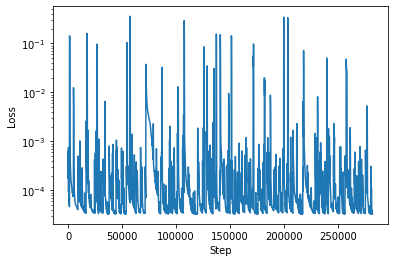

In [25]:
plt.plot([x*100 for x in range(len(lossList))], lossList)
plt.ylabel('Loss')
plt.xlabel('Step')
plt.yscale("log")
plt.show()

## Result

### best parameters

In [26]:
ys = cls_predict(xs, 50, best_params)

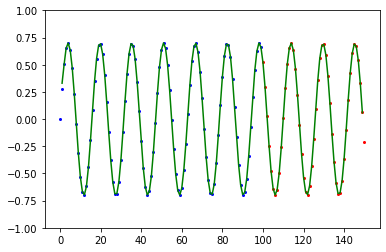

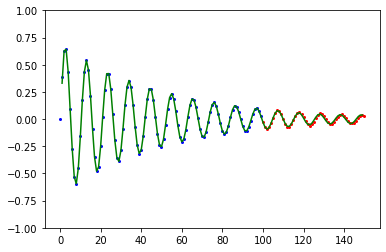

In [27]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

### final parameters

In [28]:
ys = cls_predict(xs, 50, params)

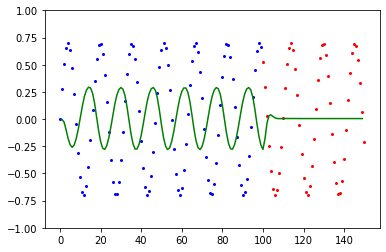

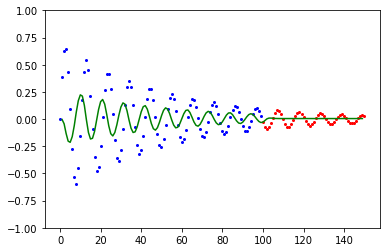

In [29]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

## Load & find the best parameters

In [22]:
# load
# Loss, minLoss, params, best_params, loc_params_list, reset_steps
with open(nb_name+'_state.pkl', 'rb') as f:
    lossList, minLoss, params, best_params, loc_params_list, reset_steps = pickle.load(f)

In [23]:
test_result = []
min_loss = 1000
k = 0
for i in reset_steps[1:]:
    k += 1
    j = int(i/100 -1)
    i_loss = lossList[j]
    i_params = loc_params_list[k]
    
    ys = cls_predict(xs, 50, i_params)
    
    t_loss = jnp.mean((true2[:,:-1]-ys[:,-50:,0])**2)
    test_result.append([i,i_loss,t_loss,i_params,ys])
    if t_loss < min_loss:
        min_loss = t_loss
        min_idx = k-1
        min_ys = ys
        
test_result[min_idx]

[282400,
 Array(3.33770086e-05, dtype=float64),
 Array(1.46260645e-05, dtype=float64),
 [((Array([[ 1.07649603, -3.07989747,  3.41504336, -0.09928685, -0.04682149,
            -0.11347997]], dtype=float64),
    Array([[ 0.7807978 , -1.47421421, -0.48012063, -1.25552671,  2.57779995,
            -8.41563808],
           [ 5.46098821, -3.33193543, -0.81762297, -0.13437294, -1.34530694,
             4.55597376],
           [-2.60502716, -0.73758507, -1.96599577,  0.73918836, -2.05247929,
            -6.71549617],
           [-0.92316561, -3.39219201,  2.43772534,  0.50471493, -2.45778677,
             2.14550915],
           [ 0.47226906, -0.37240212, -1.26995469, -1.48213012,  0.91514511,
             1.68703863],
           [-1.65787344,  2.05658796, -2.07620631, -0.75269558,  2.29497308,
             2.69035819]], dtype=float64),
    Array([-2.14396518,  1.86084234, -0.92448685, -5.53277654, -1.81727793,
            1.05609813], dtype=float64)),
   (Array([[ 0.99590955,  0.42998313, -1

In [24]:
# Save results
# [[i,i_loss,t_loss,i_params,ys]...]
with open(nb_name+'_test_result.pkl', 'wb') as f:
    pickle.dump(test_result, f)

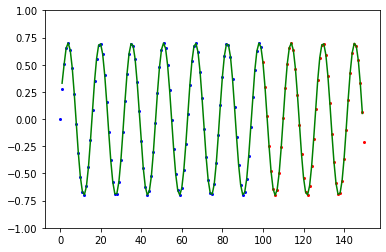

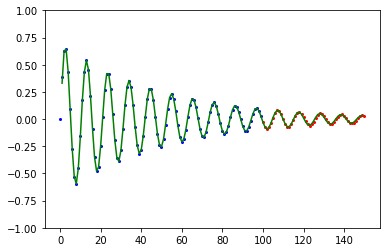

In [32]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(min_ys[idx])))+1, min_ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

best: [282400, Array(3.33770086e-05, dtype=float64), Array(1.46260645e-05, dtype=float64)]
9100 4.038047952407772e-05 0.05092964432147521


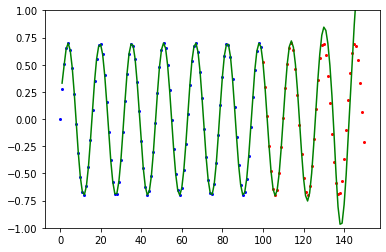

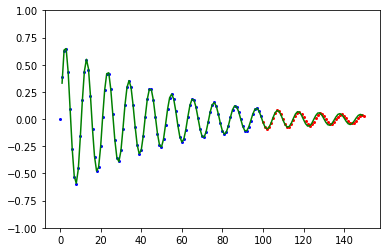

16700 3.419746672819112e-05 0.1001860205879887


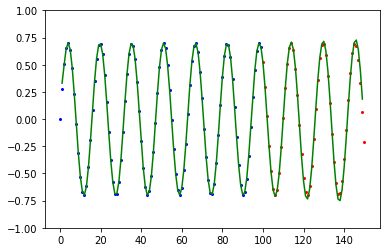

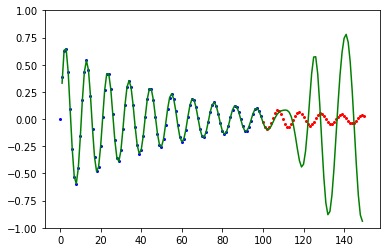

25200 3.468340024442162e-05 0.17435348104854168


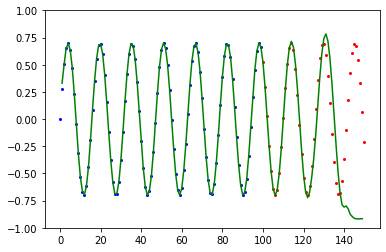

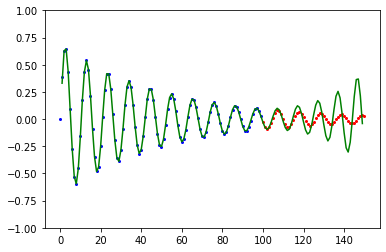

28400 3.370025221412144e-05 0.00018998856073890278


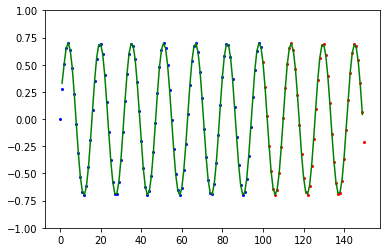

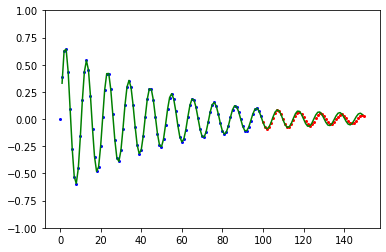

32300 3.40606028158063e-05 0.00017472772128416608


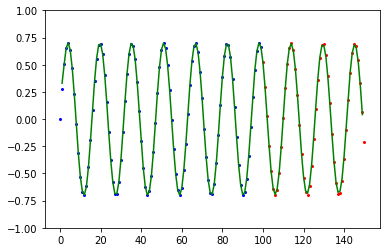

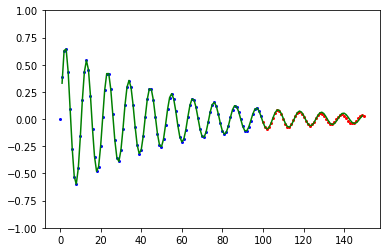

38100 3.316378355016981e-05 0.0004433059910602205


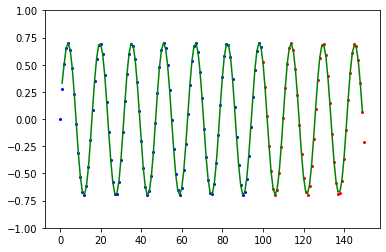

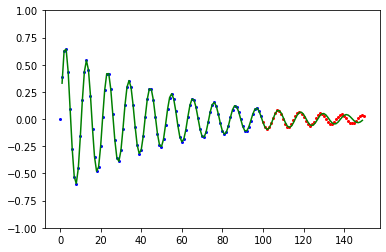

44500 3.341916832089227e-05 0.019860690582590445


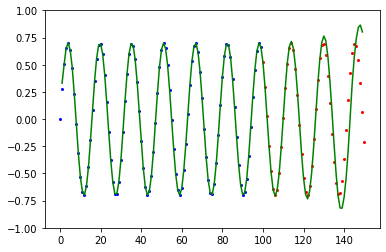

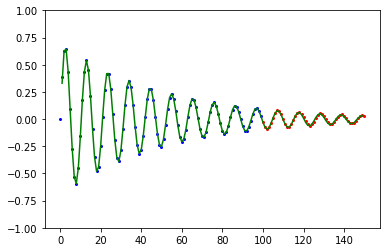

49400 3.345971049141801e-05 0.002870735424469062


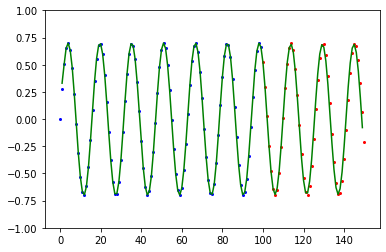

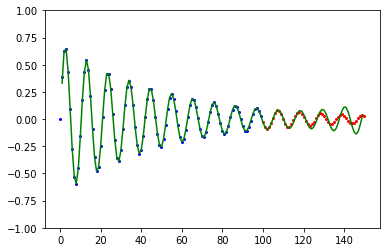

54000 3.318024329542953e-05 3.86588478043049e-05


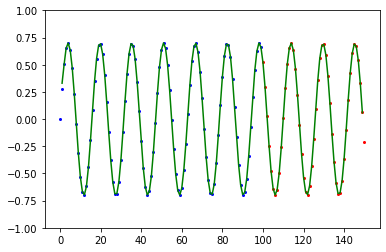

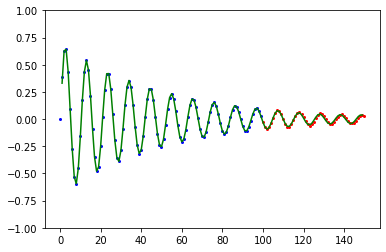

63200 3.413861785299445e-05 0.001770130676648165


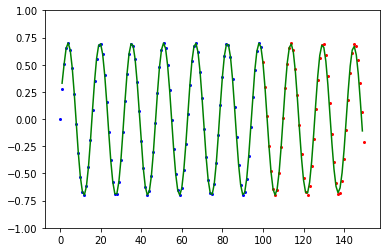

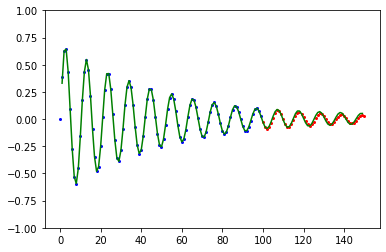

67200 3.426567774318128e-05 0.12460568895858372


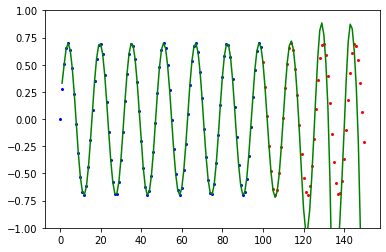

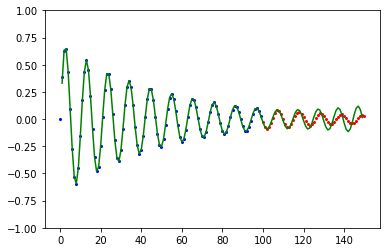

71500 3.396491431714114e-05 0.010105091489505554


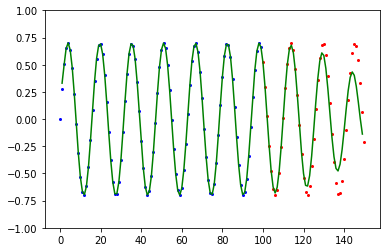

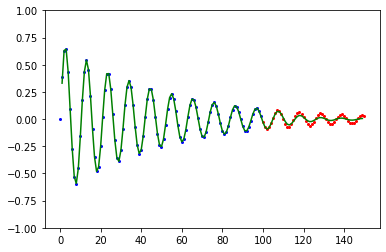

85900 3.340142617707763e-05 0.0004919164487461299


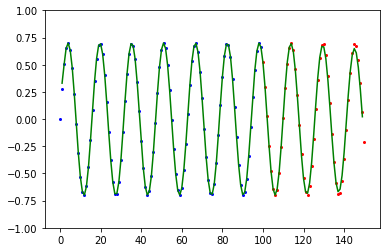

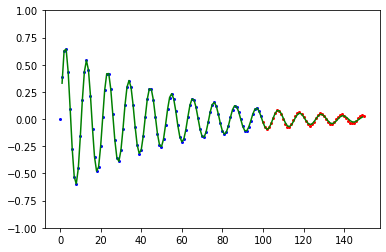

93500 3.358323737598887e-05 0.0026086041438274786


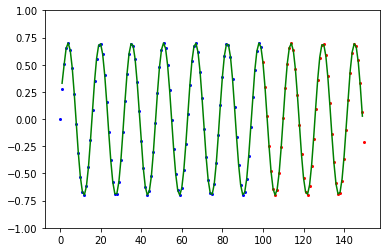

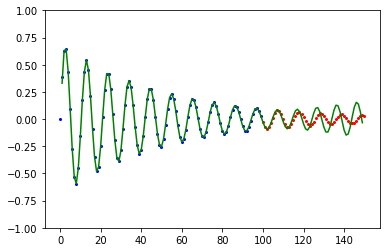

96900 3.3635672622311234e-05 0.035965698418399174


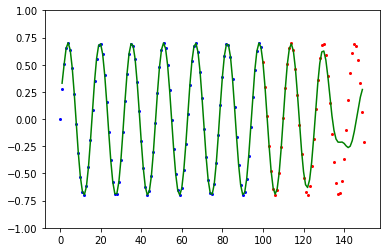

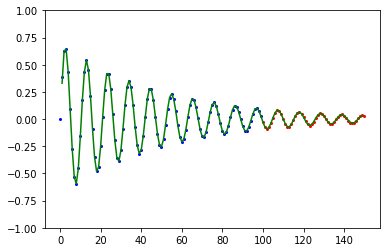

101400 3.350623158913267e-05 0.0006080140757559104


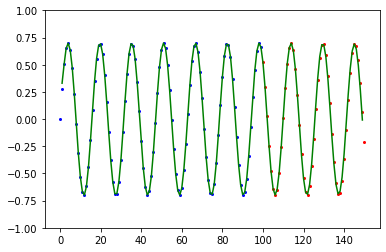

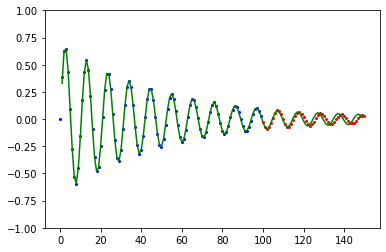

106900 3.461179721820003e-05 1.2837466287358286


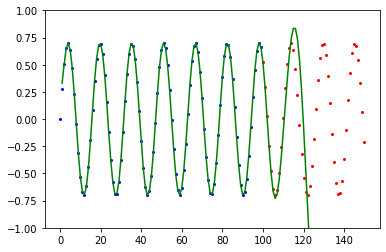

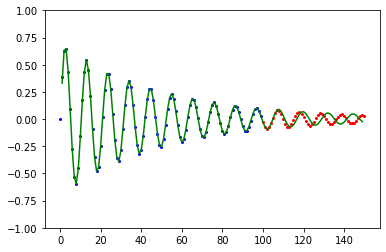

120100 3.319309724218954e-05 0.00048366360118000655


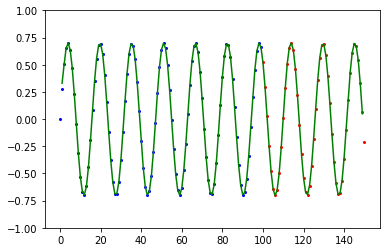

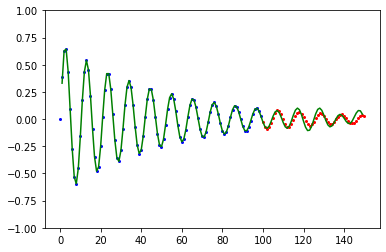

124700 3.449167536955695e-05 0.06327749999490599


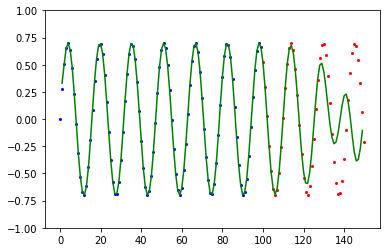

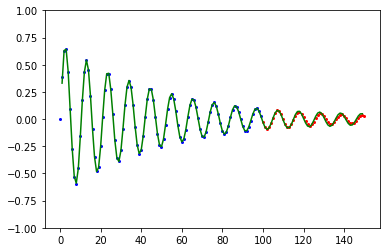

128100 3.439487193431164e-05 0.021622668005505007


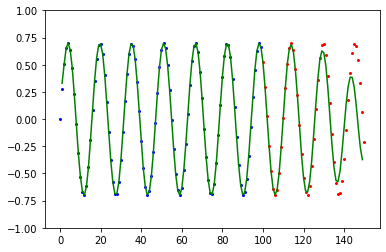

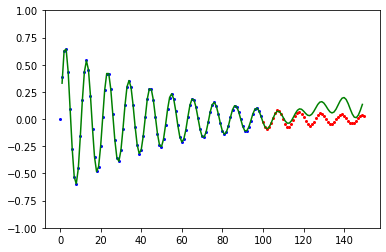

134400 3.336990778038845e-05 0.007513216092439918


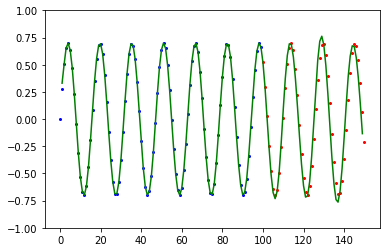

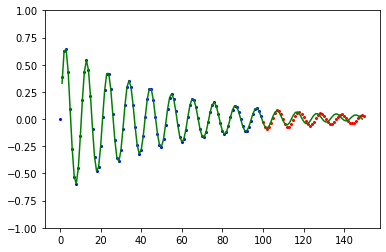

140600 3.7784214264033046e-05 0.008098648871841484


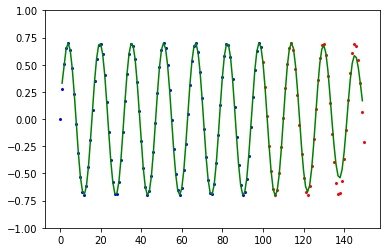

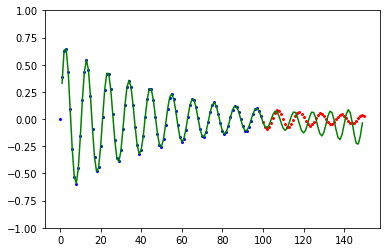

147600 3.462629855614287e-05 0.23912713304878985


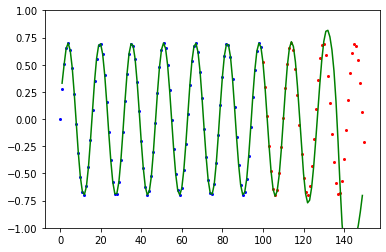

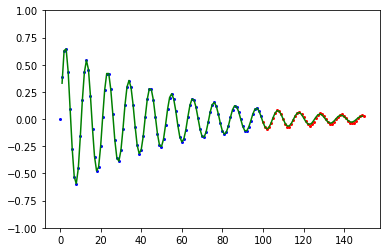

150200 3.3657948413442616e-05 0.0005526499107645023


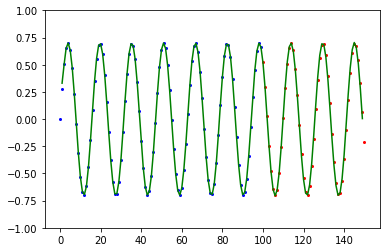

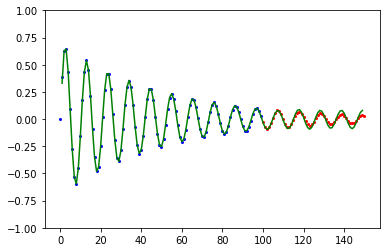

155100 3.330435149946816e-05 0.0606191591174583


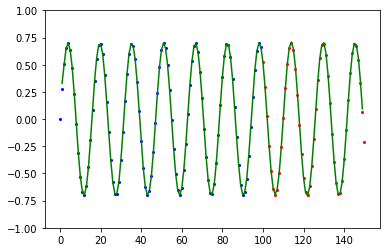

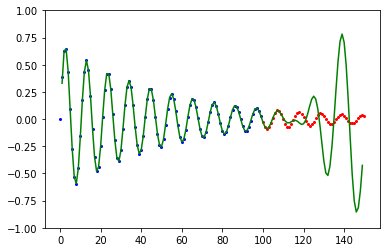

158700 3.38723706689384e-05 0.001514565891983875


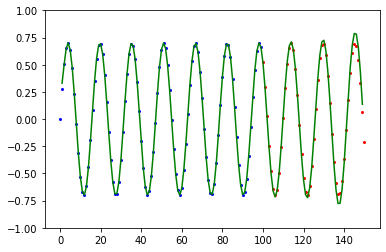

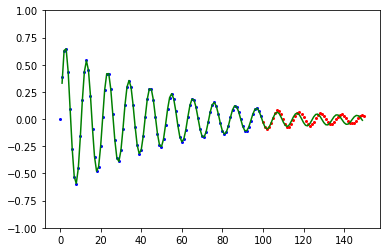

163800 3.531124593360583e-05 0.0026721292919413497


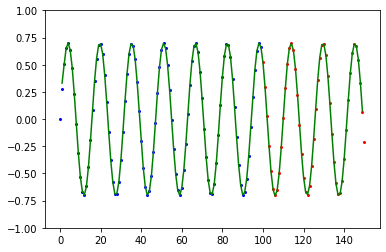

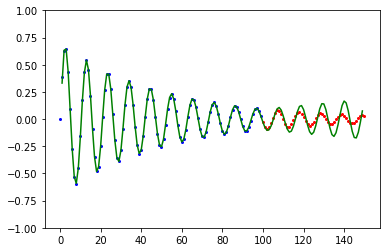

169100 3.4979339843555984e-05 0.006349167286713993


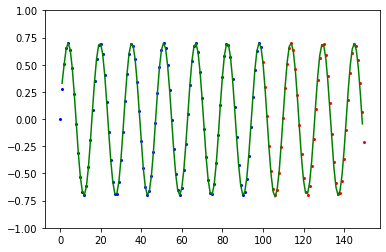

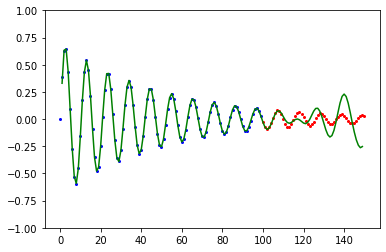

176200 3.326233812021904e-05 0.00036955170614197836


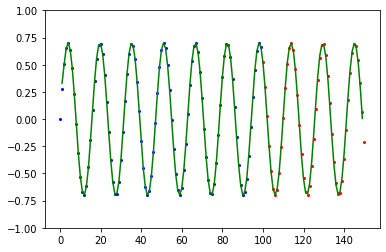

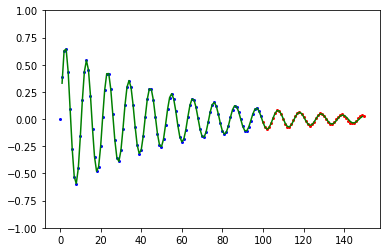

180800 3.3890662160982616e-05 0.0002732183717764758


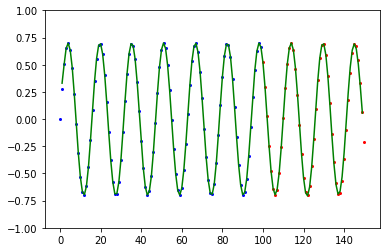

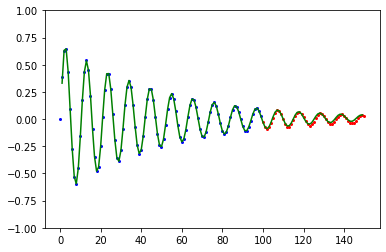

184600 3.4160454241009334e-05 0.0007776531856018074


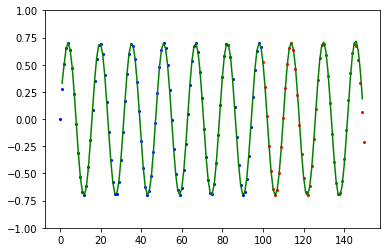

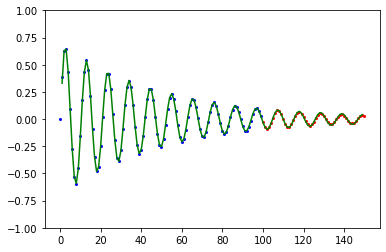

190800 3.851078792744174e-05 0.0013052650761545942


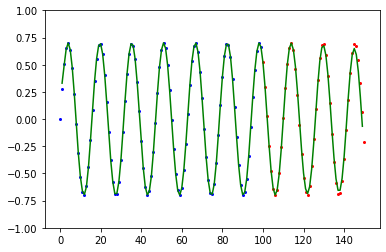

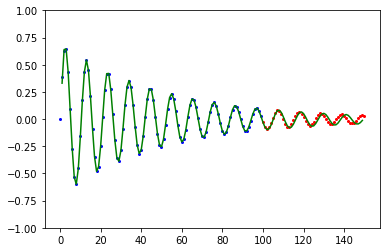

195400 3.475768601065049e-05 0.00024235682624299071


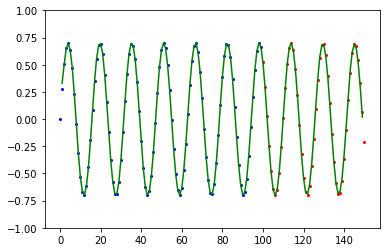

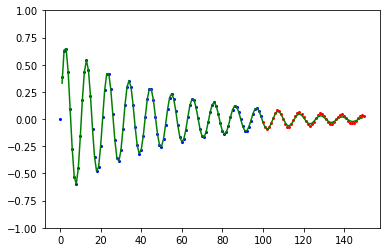

199200 3.4783198697888156e-05 0.13190087504104447


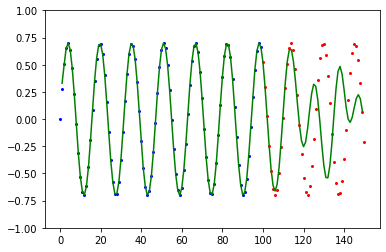

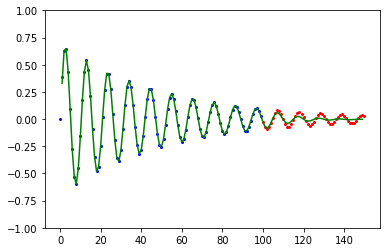

203100 3.48320319623331e-05 0.047384088921500284


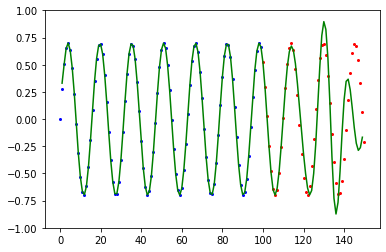

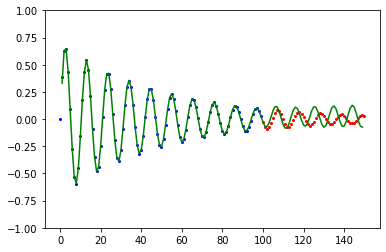

208600 3.4370890163591064e-05 6.572411819705002e-05


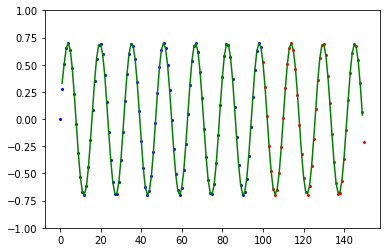

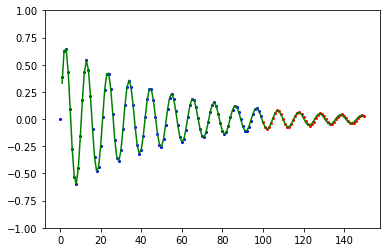

217700 3.322892405291355e-05 0.4417785286372844


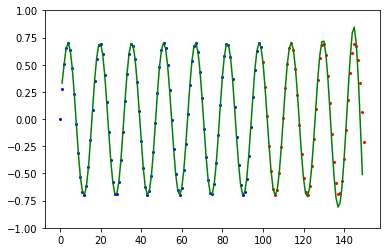

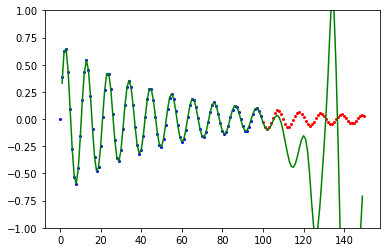

229200 3.384647600457904e-05 0.001798128013907256


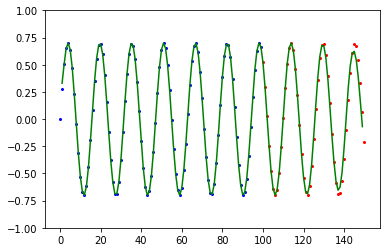

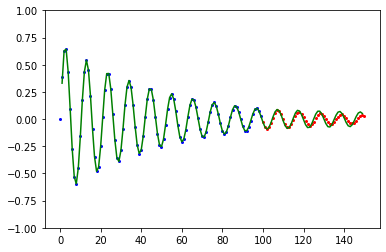

233100 3.3603986829939145e-05 0.07347625450936572


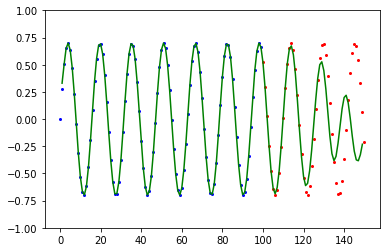

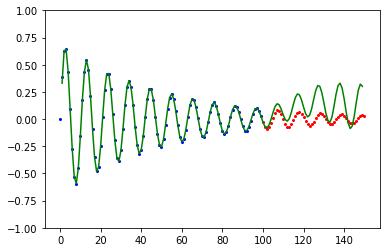

238400 3.342024244370511e-05 0.006631556854195355


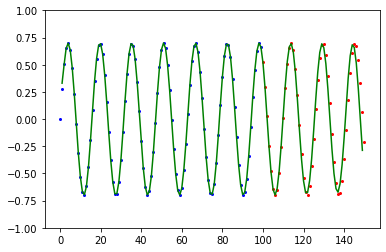

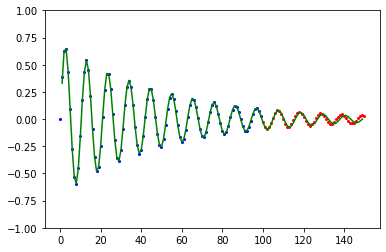

241500 3.3486752244939114e-05 0.00044995059633334833


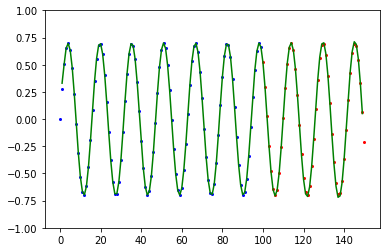

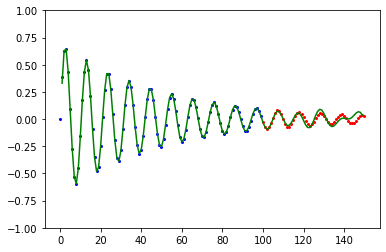

246100 3.685186123335819e-05 0.02948545530664465


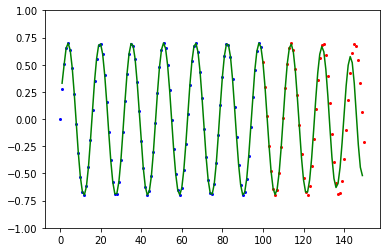

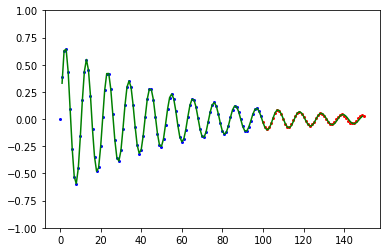

251900 3.371369164576894e-05 0.007709044381524426


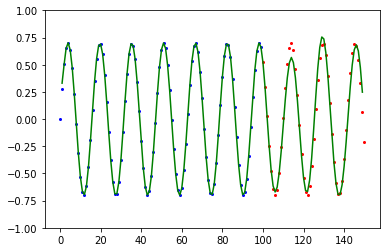

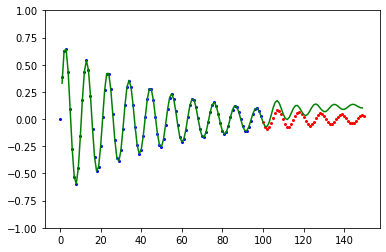

256900 3.336365097849541e-05 0.004380346591370442


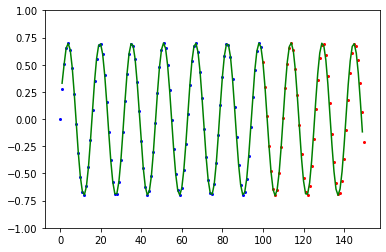

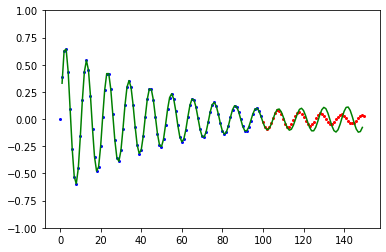

258700 0.027547584211993277 0.09928735227449345


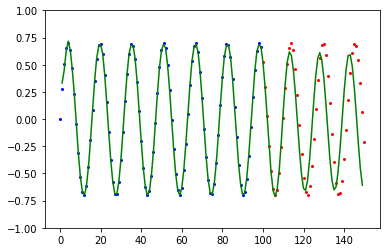

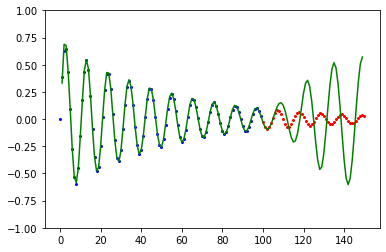

265400 3.45339501705276e-05 0.00023198866220433656


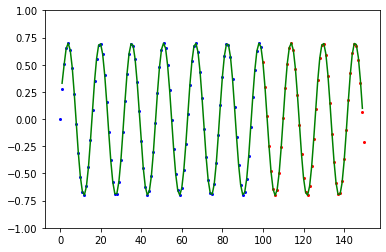

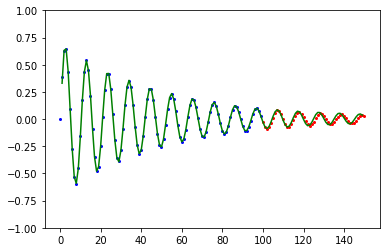

269400 3.3994739754702075e-05 0.015763873139743312


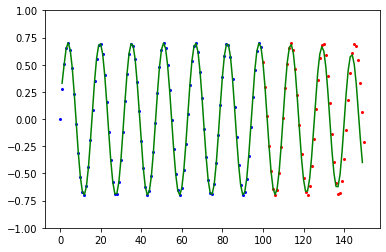

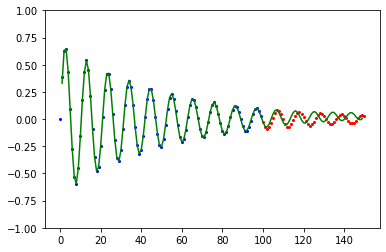

272100 3.3794867891472186e-05 0.012161952515307954


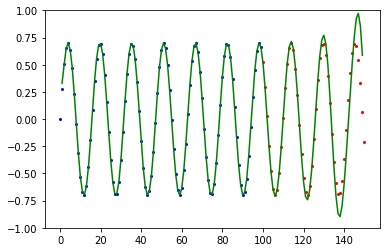

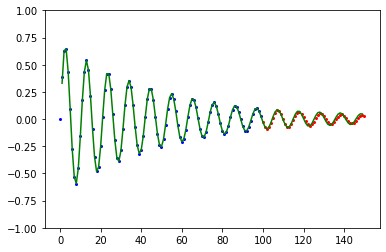

275800 3.381742319889584e-05 0.0010712927441376826


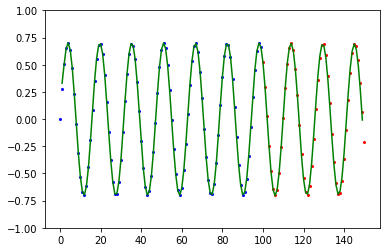

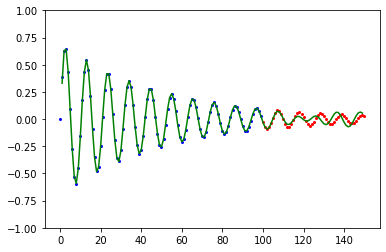

282400 3.337700859197641e-05 1.4626064477812392e-05


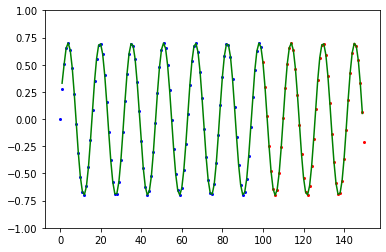

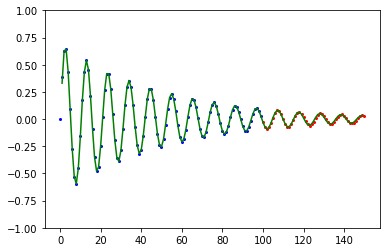

In [33]:
print('best:', test_result[min_idx][0:3])
for pak in test_result:
    i, i_loss, t_loss, _, ys = pak
    print(i, i_loss, t_loss)
    for idx in [0, 1]:
        plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
        plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
        plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
        plt.ylim(-1,1)
        plt.show()

In [34]:
sum([_[2] for _ in test_result])/len(test_result)

Array(0.06194677, dtype=float64)

In [35]:
len(test_result)

50